## PyTorch 

### 파이토치 기본

- 텐서 개념
- Numpy와 차이점

### 신경망 핵심원리

- 신경망 개념
- 신경망 구현순서

In [1]:
# 설치 확인
import torch

In [2]:
torch.__version__

'2.12.0+cu126'

In [ ]:
# GPU 사용가능(가속실행) 여부 확인
torch.cuda.is_available()

True

In [4]:
# OpenCV 포함하기
import cv2
cv2.__version__

'4.13.0'

In [63]:
# OpenCV GPU 가속여부 확인
cv2.cuda.getCudaEnabledDeviceCount()

0

### 파이토치 기본

- 텐서(Tenser) 개념
    - 딥러닝 모델을 만들때 가장 기본이 되는 구조
    - 숫자를 담는 다차원 배열
    - 수학에서 사용하는 행렬(Matrix)를 일반화한 구조

- 텐서의 종류
    - 스칼라 : 0차원 텐서(`5`)
    - 벡터 : 1차원 텐서(`[1, 3, 5, 7, 9]`)
    - 행렬 : 2차원 텐서(`[[1, 2], [3, 4]]`)
    - 텐서 : n차원 텐서. 딥러닝에서 흔히 다루는 데이터 구조

    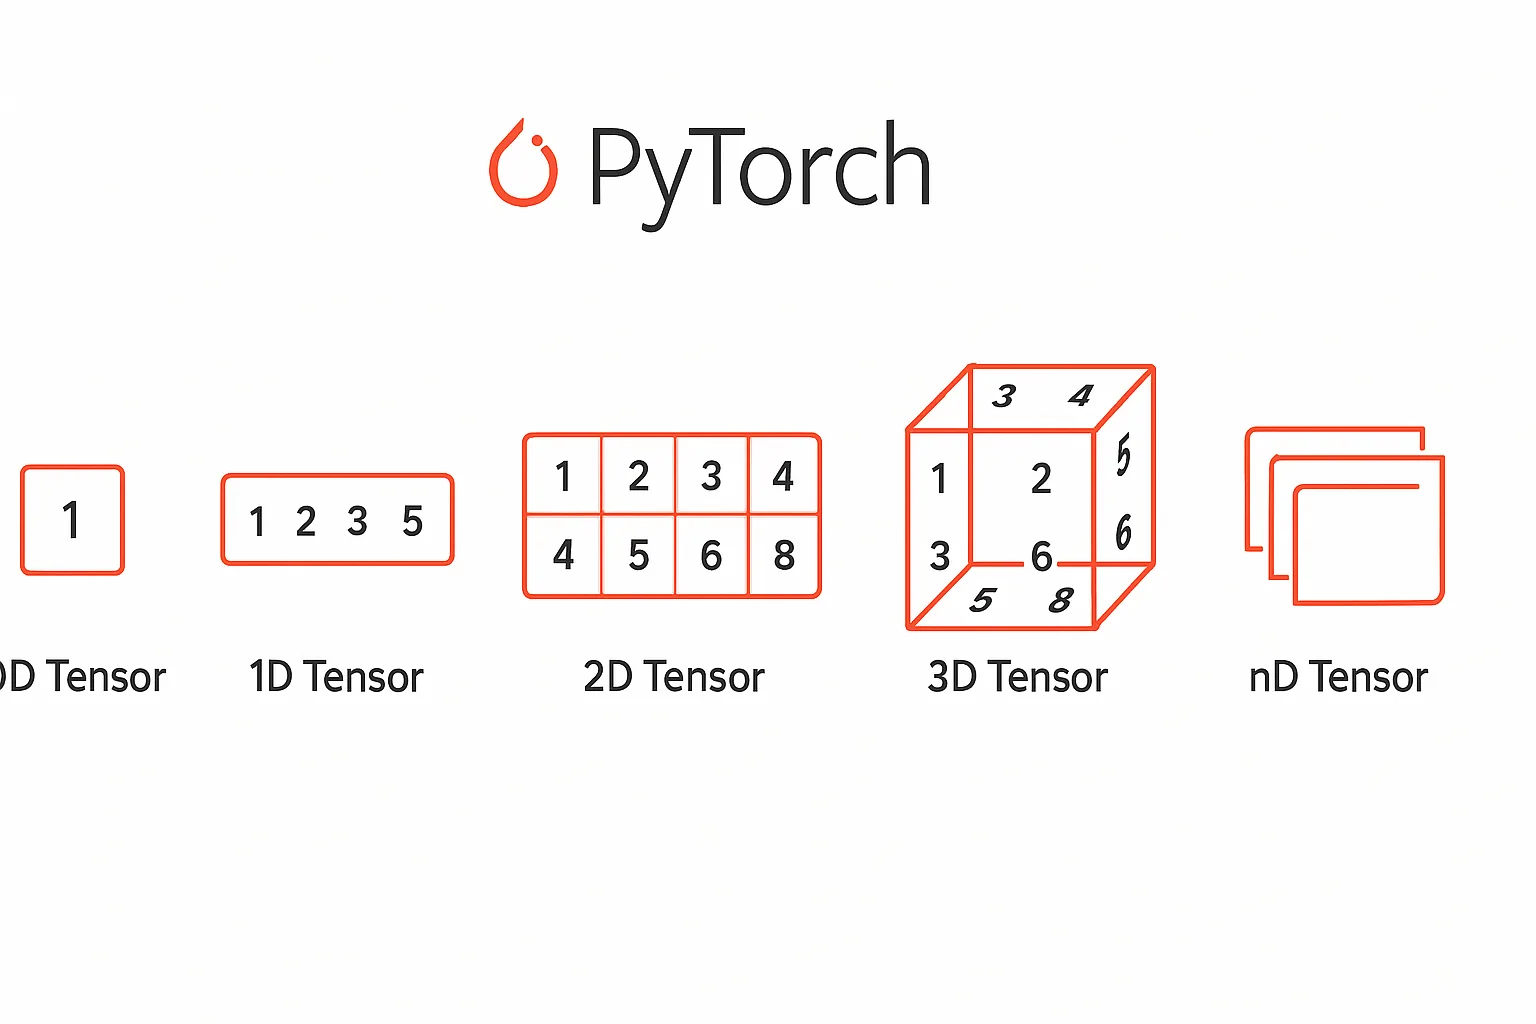

- Numpy와 차이점

In [23]:
# 텐서 만들기
## 스칼라(0차원 텐서) 생성
x = torch.tensor(5)

print(x)
print(x.dim()) # 텐서 차원수 확인

tensor(5)
0


In [8]:
## 벡터(1차원 텐서) 생성
x = torch.tensor([1, 3, 5, 7, 9])

print(x)
print(x.dim())

tensor([1, 3, 5, 7, 9])
1


In [ ]:
## 행렬, 매트릭스(2차원 텐서) 생성
x = torch.tensor([[1.1,2.0], [3.0,4.1]])

print(x)
print(x.dim())

tensor([[1, 2],
        [3, 4]])
2


In [15]:
## 3차원 텐서 생성
x = torch.tensor([[[1,2,3],[4,5,6],[7,8,9]],[[10,11,12],[13,14,15],[16,17,18]],[[19,20,21],[22,23,24],[25,26,27]]])

print(x)
print(x.dim())

tensor([[[ 1,  2,  3],
         [ 4,  5,  6],
         [ 7,  8,  9]],

        [[10, 11, 12],
         [13, 14, 15],
         [16, 17, 18]],

        [[19, 20, 21],
         [22, 23, 24],
         [25, 26, 27]]])
3


In [20]:
# 텐서 속성 확인
x.dtype # 텐서 데이터 타입

torch.float32

In [ ]:
# 텐서크기 [] 0차원 [3] 1차원 [2,2] 2차원 [3,2,1] 3차원
x.shape

torch.Size([])

In [25]:
# 텐서가 위치한 장치 확인(cpu 또는 gpu)
x.device

device(type='cpu')

#### 정리
- torch.tensor 의 인자(파라미터)로 파이썬 리스트나 넘파이 배열을 넣을 수 있음

#### 많이 사용되는 텐서 함수
- 같은 크기의 다른 텐서를 사용 중
- 

In [26]:
# 모든 원소가 0인 텐서 만들기
t_zeros = torch.zeros(2, 3) # 2x3 짜리 매트릭스 생성
t_zeros

tensor([[0., 0., 0.],
        [0., 0., 0.]])

In [29]:
t_zeros2 = torch.zeros_like(t_zeros)
t_zeros2

tensor([[0., 0., 0.],
        [0., 0., 0.]])

In [27]:
# 모든 원소가 1인 텐서
t_ones = torch.ones(2, 3)
t_ones

tensor([[1., 1., 1.],
        [1., 1., 1.]])

In [28]:
# 0~1 사이의 균등분포를 가지는 랜덤 텐서 만들기
t_randoms = torch.rand(2, 3)
t_randoms

tensor([[0.8402, 0.0373, 0.1787],
        [0.1569, 0.6583, 0.2072]])

### 텐서 연산

- 사칙연산, 곱셈, 전치... 여러 연산방법 제공

In [34]:
x = torch.tensor([[1,2], [3,4]])
y = torch.tensor([[5,6],[7,8]])

# 덧셈
print(x + y)
print(torch.add(x, y))

tensor([[ 6,  8],
        [10, 12]])
tensor([[ 6,  8],
        [10, 12]])


In [35]:
# 뺄셈
print(x - y)
print(torch.subtract(x, y))

tensor([[-4, -4],
        [-4, -4]])
tensor([[-4, -4],
        [-4, -4]])


In [37]:
# 곱셈
print(x * y)
print(torch.mul(x, y))

tensor([[ 5, 12],
        [21, 32]])
tensor([[ 5, 12],
        [21, 32]])


In [39]:
# 행렬곱셈
print(x @ y)
print(torch.matmul(x, y))

tensor([[19, 22],
        [43, 50]])
tensor([[19, 22],
        [43, 50]])


## 브로드캐스팅(BoardCasting):크기가 다른 텐서 간의 연산

In [40]:
# x = [[1,2],[3,4]]
scalar = 10

print(x + scalar)

tensor([[11, 12],
        [13, 14]])


## 인덱싱, 슬라이싱 : 필요요소 접근, 필요요소만 잘라내기

In [41]:
x = torch.tensor([[10,20,30],
                  [40,50,60],
                  [70,80,90]])
print(x)

tensor([[10, 20, 30],
        [40, 50, 60],
        [70, 80, 90]])


In [43]:
# 2행 3열의 값을 조회
x[1, 2]

tensor(60)

In [44]:
# 첫번째 행 모든 열의 원소를 슬라이싱
x[0, :]

tensor([10, 20, 30])

In [45]:
# 2열의 모든 원소 슬라이싱
x[:, 1]

tensor([20, 50, 80])

In [46]:
# 1행~2행까지, 2열~3열까지 슬라이싱
x[0:2, 1:3]

tensor([[20, 30],
        [50, 60]])

#### 문제

1. 2행 4열의 모든 원소가 9인 텐서를 만드시오
2. 두 텐서 a, b를 정의하고, 둘의 더한 결과를 출력하시오
    ```python
    a - [1,2,3] 
    b - [4,8,10]
    ```

3. 텐서 x에서 6과 90만 선택해서 새 텐서 y를 만드시오
    ```python
    x : [[1, 2, 3],
           [4, 5, 6],
           [70, 80, 90]]
    ```
4. 텐서 m과 n의 행렬곱셈 결과를 출력하시오
    ```python
    m : [[1,3],[5,7]]
    n : [[1,0],[0,1]]
    ```

In [51]:
# 1문제
c = torch.ones(2, 4)
print(c * 9)

tensor([[9., 9., 9., 9.],
        [9., 9., 9., 9.]])


In [53]:
c = torch.full((2, 4), 9)
c

tensor([[9, 9, 9, 9],
        [9, 9, 9, 9]])

In [54]:
# 문제2
a = torch.tensor([1, 2, 3])
b = torch.tensor([4, 8, 10])
a + b


tensor([ 5, 10, 13])

In [58]:
# 문제 3
x = torch.tensor([[1, 2, 3], 
           [4, 5, 6],
           [70, 80, 90]])
print(x)

y = torch.tensor([x[1, 2], x[2, 2]])
print(y)    # 벡터

tensor([[ 1,  2,  3],
        [ 4,  5,  6],
        [70, 80, 90]])
tensor([ 6, 90])


In [ ]:
# 문제 4
m = torch.tensor([[1, 3], [5, 7]])
n = torch.tensor([[1, 0], [0, 1]]) # 단위행렬

# m @ n
m @ n

tensor([[1, 3],
        [5, 7]])

In [60]:
# 0부터 9까지
torch.arange(0, 10)

tensor([0, 1, 2, 3, 4, 5, 6, 7, 8, 9])

#### PyTorch와 Numpy 차이점
- 넘파이와 파이토치의 배열은 매우 비슷
- 둘다 다차원 배열 처리
- 연산도 거의 동일
- 문법도 거의 동일

In [61]:
import numpy as np

In [62]:
n_array = np.array([1,3,5,7,9])
print(n_array)

t_array = torch.tensor([1,3,5,7,9])
print(t_array)

[1 3 5 7 9]
tensor([1, 3, 5, 7, 9])


#### 텐서와 넘파이 차이점

1. GPU 지원
    - 파이토치는 GPU 사용해서 연산속도를 크게 높일 수 있음
    - CPU 사용때보다 병렬연산이 많이 필요
    - Numpy 경우는 GPU사용하려면 CuPy라이브러리 사용해야
    - 순차적인 소량 작업은 CPU가 더 빠름. 수천개의 코어로 병렬작업시는 GPU 효과적

2. 자동미분 기능
    - 텐서로 미분값을 자동 계산해주는 기능. Autograd 내장
    - 딥러닝 모델 학습시 경사하강법 구현 때 사용
    - Numpy는 직접 미분값을 계산

#### 결론
- 넘파이와 동일한 강력한 다차원 배열 지원, 딥러닝에 필수인 GPU가속과 자동미분 기능을 제공

#### 많이 쓰이는 분야
1. 생성형 AI / LLM
2. 컴퓨터 비전 - YOLO
3. 자연어 처리
4. 음성 AI
5. Physical AI
6. 강화학습(RL)
7. 의료/바이오

- 생성형 AI 이후로 Tensorflow에서 PyTorch로 많이 이전되는 상황